Generating model...
Model generated with 4221 state-action pairs
Starting policy iteration...
Policy iteration 1...


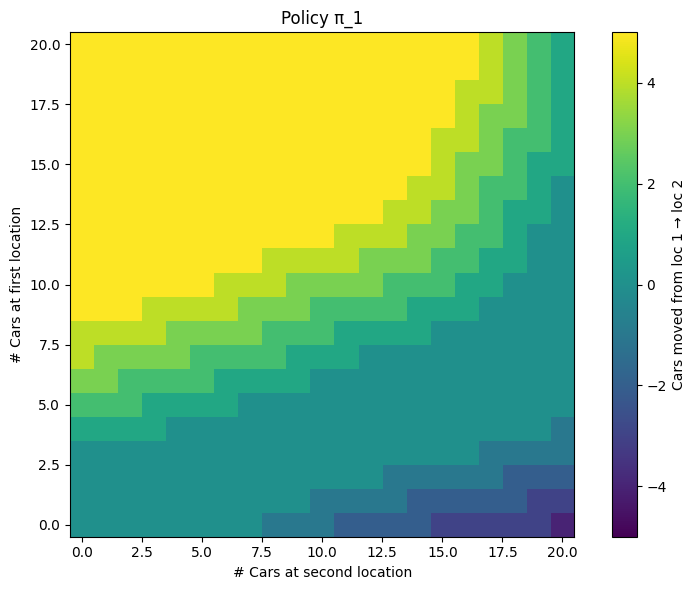

Policy iteration 2...


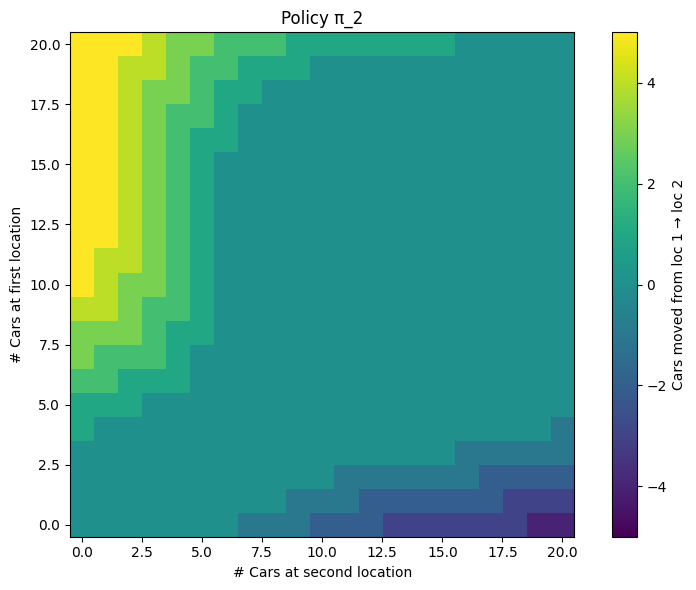

Policy iteration 3...


In [ ]:
from collections import namedtuple
import numpy as np
import matplotlib.pyplot as plt
import math


In [ ]:
MAX_CARS = 20
MAX_MOVE = 5

LAMBDA_RENT_1 = 3
LAMBDA_RENT_2 = 4
LAMBDA_RETURN_1 = 3
LAMBDA_RETURN_2 = 2

RENT_CREDIT = 10
MOVE_COST = 2

GAMMA = 0.9

THETA = 1e-4

MAX_POISSON = 10

In [ ]:
def poisson_pmf(k, lamda):
    return (lamda**k) * np.exp(-lamda) / math.factorial(k)

def get_poisson_probs(lamda):
    probs = [poisson_pmf(n, lamda) for n in range(MAX_POISSON)]
    probs.append(1 - sum(probs))
    return probs

poisson_cache = {
    LAMBDA_RENT_1: get_poisson_probs(LAMBDA_RENT_1),
    LAMBDA_RENT_2: get_poisson_probs(LAMBDA_RENT_2),
    LAMBDA_RETURN_1: get_poisson_probs(LAMBDA_RETURN_1),
    LAMBDA_RETURN_2: get_poisson_probs(LAMBDA_RETURN_2)
}

In [ ]:
S = [(i, j) for i in range(MAX_CARS + 1) for j in range(MAX_CARS + 1)]
A = list(range(-MAX_MOVE, MAX_MOVE + 1))

def is_valid(s, a):
    if a > 0:
        return s[0] >= a
    elif a < 0:
        return s[1] >= -a
    else:
        return True

def generate_model():
    P = {}

    for s in S:
        cars1, cars2 = s

        for a in A:
            if not is_valid(s, a):
                continue

            cars1_moved = cars1 - a
            cars2_moved = cars2 + a

            move_cost = MOVE_COST * abs(a)

            P_sa = {}

            for req1 in range(MAX_POISSON + 1):
                for req2 in range(MAX_POISSON + 1):
                    for ret1 in range(MAX_POISSON + 1):
                        for ret2 in range(MAX_POISSON + 1):

                            prob = (poisson_cache[LAMBDA_RENT_1][req1] *
                                   poisson_cache[LAMBDA_RENT_2][req2] *
                                   poisson_cache[LAMBDA_RETURN_1][ret1] *
                                   poisson_cache[LAMBDA_RETURN_2][ret2])

                            if prob < 1e-10:
                                continue

                            rented_1 = min(cars1_moved, req1)
                            rented_2 = min(cars2_moved, req2)

                            cars1_after_rent = cars1_moved - rented_1
                            cars2_after_rent = cars2_moved - rented_2

                            cars1_next = min(MAX_CARS, cars1_after_rent + ret1)
                            cars2_next = min(MAX_CARS, cars2_after_rent + ret2)

                            s_next = (cars1_next, cars2_next)

                            reward = (rented_1 + rented_2) * RENT_CREDIT - move_cost

                            key = (s_next, reward)

                            if key not in P_sa:
                                P_sa[key] = 0.0

                            P_sa[key] += prob

            P[(s, a)] = P_sa

    return P

In [ ]:
def render_policy(policy, title=""):
    policy_array = np.zeros((MAX_CARS + 1, MAX_CARS + 1))

    for s, a in policy.items():
        cars1, cars2 = s
        policy_array[cars1, cars2] = a

    plt.figure(figsize=(8, 6))
    plt.imshow(
        policy_array,
        origin="lower",
        cmap="viridis",
        vmin=-5,
        vmax=5
    )
    plt.colorbar(label="Cars moved from loc 1 → loc 2")
    plt.xlabel("# Cars at second location")
    plt.ylabel("# Cars at first location")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def evaluate(V, pi, P):
    while True:
        delta = 0.0

        for s in S:
            v_old = V[s]
            a = pi[s]

            if (s, a) not in P:
                continue

            transitions = P[(s, a)]

            v_new = 0.0
            for (s_next, r), prob in transitions.items():
                v_new += prob * (r + GAMMA * V[s_next])

            V[s] = v_new
            delta = max(delta, abs(v_old - v_new))

        if delta < THETA:
            break


In [ ]:
def improve(V, pi, P):
    policy_stable = True

    for s in S:
        old_action = pi[s]
        best_action = old_action
        best_value = -1e9

        for a in A:
            if not is_valid(s, a):
                continue

            if (s, a) not in P:
                continue

            v = 0.0
            for (s_next, r), prob in P[(s, a)].items():
                v += prob * (r + GAMMA * V[s_next])

            if v > best_value:
                best_value = v
                best_action = a

        pi[s] = best_action
        if old_action != best_action:
            policy_stable = False

    return policy_stable


In [ ]:
if __name__ == "__main__":
    print("Generating model...")
    P = generate_model()
    print(f"Model generated with {len(P)} state-action pairs")

    V = {s: 0.0 for s in S}
    pi = {s: 0 for s in S}

    policy_stable = False
    n_policy_iterations = 0

    print("Starting policy iteration...")

    while not policy_stable:
        print(f"Policy iteration {n_policy_iterations + 1}...")
        evaluate(V, pi, P)
        policy_stable = improve(V, pi, P)
        render_policy(pi, title=f"Policy π_{n_policy_iterations + 1}")
        n_policy_iterations += 1

    print(f"Converged after {n_policy_iterations} iterations")
    render_policy(pi, title="Final Optimal Policy")